In [338]:
import glob

dataset = []

for i, file in enumerate(glob.glob("psmImages/*.txt")):
    print(f"file index {i}: {file[10:-4]}")

    with open(file) as f:
        lines = [line.strip() for line in f.readlines()]
        
    num_img = int(lines[0])
    image_paths = lines[1:1+num_img]
    mask = lines[-1]

    dataset.append((num_img, image_paths, mask))

file index 0: buddha
file index 1: cat
file index 2: chrome
file index 3: gray
file index 4: horse
file index 5: owl
file index 6: rock


In [339]:
print(dataset[1])

(12, ['psmImages/cat/cat.0.png', 'psmImages/cat/cat.1.png', 'psmImages/cat/cat.2.png', 'psmImages/cat/cat.3.png', 'psmImages/cat/cat.4.png', 'psmImages/cat/cat.5.png', 'psmImages/cat/cat.6.png', 'psmImages/cat/cat.7.png', 'psmImages/cat/cat.8.png', 'psmImages/cat/cat.9.png', 'psmImages/cat/cat.10.png', 'psmImages/cat/cat.11.png'], 'psmImages/cat/cat.mask.png')


In [340]:
import cv2
import numpy as np

chrome_data = dataset[2]
num_img, chrome_img_paths, mask_path = chrome_data
num_img -= 1

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
print(mask.shape)
print(mask)

(340, 512)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


# T1
---

In [ ]:
# center of mass (perfect circle assumption)
ys, xs = np.where(mask > 0)

cx = np.mean(xs)
cy = np.mean(ys)

print(f"center of mass: ({cx}, {cy})")

# radius estimation (perfect circle assumption)
r = np.mean(np.sqrt((xs - cx)**2 + (ys - cy)**2))
print(f"radius: {r}")

r = ( (xs.max() - xs.min()) + (ys.max() - ys.min()) ) / 4
print(f"radius: {r}")

# area-based radius estimation
N = np.sum(mask > 0)
r = np.sqrt(N / np.pi)
print(f"radius: {r}")

# edge-based radius estimation (perfect circle assumption)
edges = cv2.Canny(mask,50,150)
eys, exs = np.where(edges>0)

dist = np.sqrt((exs-cx)**2 + (eys-cy)**2)
r = np.mean(dist)
print(f"radius: {r}")

center of mass: (253.22103056383096, 147.73476773695245)
radius: 120.1008430129384
radius: 119.48373592416068


In [342]:
#Hough Circle Transform
circles = cv2.HoughCircles(
    mask,
    cv2.HOUGH_GRADIENT,
    dp=1,
    minDist=100,
    param1=100,
    param2=30,
    minRadius=0,
    maxRadius=0
)
print(circles)

[[[253.5 147.5 119. ]]]


In [343]:
#Distance Transform
dist = cv2.distanceTransform(mask, cv2.DIST_L2, 5)
cy, cx = np.unravel_index(np.argmax(dist), dist.shape)
r = dist[cy, cx]
print(f"center: ({cx}, {cy}), radius: {r}")

center: (253, 147), radius: 117.8356704711914


In [344]:
#least squares circle fitting
edges = cv2.Canny(mask,50,150)

ys, xs = np.where(edges > 0)

A = np.column_stack((xs, ys, np.ones(len(xs))))
b = xs**2 + ys**2

C, _, _, _ = np.linalg.lstsq(A, b, rcond=None)

cx = C[0] / 2
cy = C[1] / 2
r = np.sqrt(C[2] + cx**2 + cy**2)

print(f"center: ({cx}, {cy}), radius: {r}")

center: (253.22501577127636, 147.72990300014476), radius: 119.48436212439988


# T2
---

In [345]:
def surface_normal(x, y):
    
    nx = (x - cx) / r
    ny = (y - cy) / r
    nz = np.sqrt(1 - nx**2 - ny**2)

    return np.array([nx, ny, nz])

# T3
---

In [346]:
from tqdm import tqdm

L = []
R = np.array([0, 0, 1]) #(3,)

for p in image_paths:
    img = cv2.imread(p)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    masked_gray = cv2.bitwise_and(gray, gray, mask=mask)

    _, _, _, maxLoc = cv2.minMaxLoc(masked_gray)
    hx, hy = maxLoc

    N = surface_normal(hx, hy) #(3,)
    assert np.isclose(np.linalg.norm(N), 1)
    
    light_dir = 2 * (N @ R) * N - R #(3,)
    light_dir = light_dir / np.linalg.norm(light_dir, keepdims=True)

    L.append(light_dir)
    

L = np.array(L) #(12, 3)
print(L)
print(L.shape)

[[ 0.3347984  -0.39853373  0.85386234]
 [ 0.3347984  -0.39853373  0.85386234]
 [-0.25260383  0.07084675  0.96497256]
 [ 0.0625336  -0.27713522  0.95879384]
 [ 0.0625336  -0.27713522  0.95879384]
 [ 0.0625336  -0.27713522  0.95879384]
 [ 0.3347984  -0.39853373  0.85386234]
 [ 0.3347984  -0.39853373  0.85386234]
 [ 0.3347984  -0.39853373  0.85386234]
 [ 0.3347984  -0.39853373  0.85386234]
 [-0.55338582  0.78219123  0.28625341]
 [ 0.0625336  -0.27713522  0.95879384]]
(12, 3)


In [347]:
print("Light norms:", np.linalg.norm(L, axis=1))

print("Light z:", L[:,2])

assert np.allclose(np.linalg.norm(L, axis=1), 1, atol=1e-2)
assert np.all(L[:,2] > 0)

Light norms: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Light z: [0.85386234 0.85386234 0.96497256 0.95879384 0.95879384 0.95879384
 0.85386234 0.85386234 0.85386234 0.85386234 0.28625341 0.95879384]


# T4
---

In [348]:
buddha_data = dataset[0]
_, buddha_img_paths, mask_path = buddha_data

mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
mask = (mask > 0).astype(np.float32)

img_list = []

for p in buddha_img_paths:
    img = cv2.imread(p)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img_list.append(gray)

imgs = np.stack(img_list, axis=0) #(12, H, W)
print(imgs.shape)

(12, 340, 512)


In [349]:
N, H, W = imgs.shape
I = imgs.reshape(N, -1) #(12, H*W)
print(I.shape)

(12, 174080)


In [350]:
LT = L.T #(3, 12)
G =  np.linalg.solve(LT @ L, LT @ I) #(3, H*W)
print(G.shape)

(3, 174080)


In [351]:
G,_,_,_= np.linalg.lstsq(L, I, rcond=None)
print(G.shape)

(3, 174080)


In [352]:
mask_flat = mask.reshape(-1) > 0

I_valid = I[:, mask_flat]

G_valid, _, _, _ = np.linalg.lstsq(L, I_valid, rcond=None)

G = np.zeros((3, H*W))
G[:, mask_flat] = G_valid

In [353]:
albedo = np.linalg.norm(G, axis=0) #(H*W,)
print(albedo.shape)

(174080,)


In [354]:
normals = G / (albedo + 1e-8) #(3, H*W)
print(normals.shape)

(3, 174080)


In [355]:
albedo_map = albedo.reshape(H, W) # (H, W)
normal_map = normals.reshape(3, H, W).transpose(1, 2, 0) # (H, W, 3)
normal_map = (normal_map + 1) / 2 * 255

print(albedo_map.shape)
print(normal_map.shape)

(340, 512)
(340, 512, 3)


In [356]:
dot = normal_map @ np.array([0,0,1])

print(dot.min(), dot.max(), dot.mean())

127.5 254.89843845365988 139.00588040819744


(340, 512, 3)


Text(0.5, 1.0, 'Normal Map')

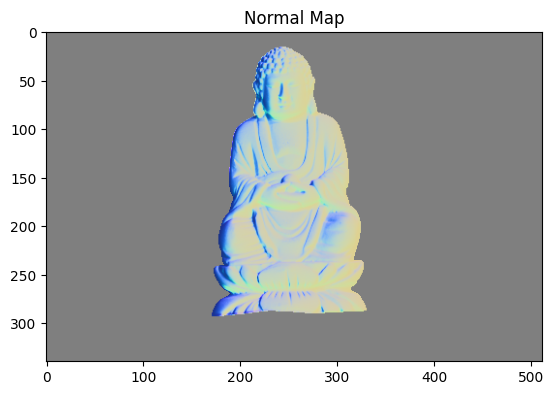

In [362]:
import matplotlib.pyplot as plt
print(normal_map.shape)
plt.imshow(normal_map.astype(np.uint8))
plt.title('Normal Map')

Text(0.5, 1.0, 'Albedo Map')

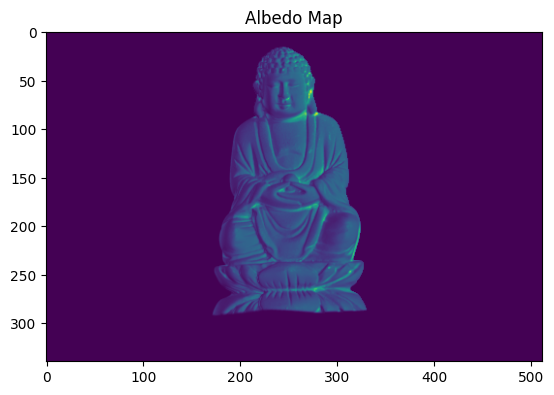

In [358]:
plt.imshow(albedo_map)
plt.title('Albedo Map')

Text(0.5, 1.0, 'Albedo Map')

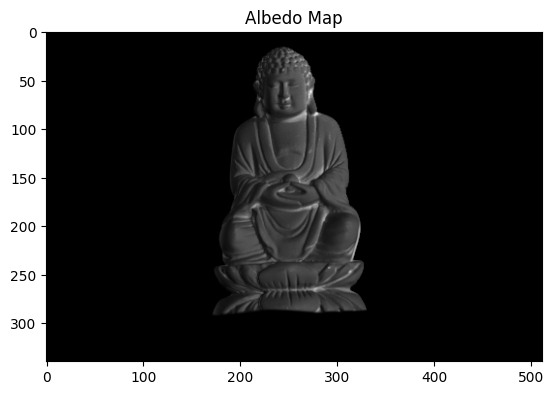

In [359]:
plt.imshow(albedo_map, cmap='gray')
plt.title('Albedo Map')

# T5
---

(340, 512)


Text(0.5, 1.0, 'Shading')

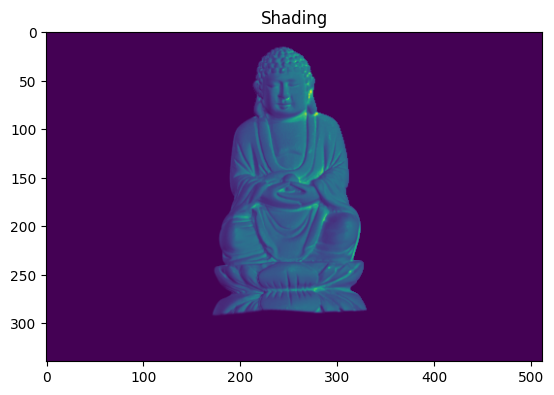

In [360]:
L_ = np.array([0, 0, 1]) #(3,)
shading = albedo_map * np.maximum(0, normal_map @ L_) #(H, W)
print(shading.shape)

plt.imshow(shading)
plt.title('Shading')

Text(0.5, 1.0, 'Shading')

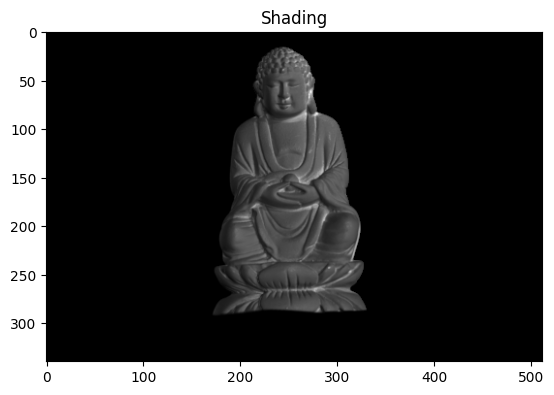

In [361]:
plt.imshow(shading, cmap='gray')
plt.title('Shading')